<a href="https://colab.research.google.com/github/Vixuz144/Simulacion-1/blob/main/Problema_Aseguradora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from random import random, gauss
import numpy as np
from numba import jit
import matplotlib.pyplot as plt

In [ ]:
@jit(nopython = True)
def aseguradora(T = 365, pol = 150, nc = 10000, c0 = 10**7, nom = 50000):
  lam = 1
  mu, sig = 35000, 5000

  ts = -np.log(random())/lam
  tnom = 15
  tpol = 30

  c = c0
  t = 0

  lc, lt = [c0], [0]

  while t<T and min(tnom, tpol) < T:
    lc.append(c)
    lt.append(t)
    t = min(ts,tnom,tpol)
    if t == ts:
      c -= gauss(mu,sig)
      text = 'Siniestro'
      ts -= np.log(random())/lam
    elif t == tnom:
      c -= nom
      text = 'Nomina'
      tnom += 15
    else:
      c += pol * nc
      text = 'Polizas'
      tpol += 30

    lc.append(c)
    lt.append(t)
    print(text, round(t,3), round(c, 3))
  print('\nGanancia:',np.round(c-c0, 3),'\nGanancia porcentual:',100 * np.round((c-c0)/c0, 3))
  return lt, lc

Siniestro 0.817 9965167.327
Siniestro 3.915 9926640.457
Siniestro 4.136 9890353.332
Siniestro 4.879 9845008.637
Siniestro 5.653 9808095.319
Siniestro 8.169 9775185.047
Siniestro 10.326 9744547.146
Siniestro 10.523 9702814.28
Siniestro 10.612 9668878.259
Siniestro 11.831 9628056.786
Siniestro 12.189 9596596.605
Siniestro 12.191 9561213.009
Siniestro 12.422 9527574.553
Siniestro 12.92 9501402.731
Siniestro 13.313 9462386.875
Siniestro 13.536 9432275.051
Siniestro 13.788 9391617.435
Nomina 15.0 9341617.435
Siniestro 15.843 9310827.641
Siniestro 16.299 9274477.267
Siniestro 18.241 9233557.336
Siniestro 20.228 9195806.618
Siniestro 20.259 9160231.475
Siniestro 21.521 9123252.159
Siniestro 22.227 9089307.696
Siniestro 23.286 9052096.717
Siniestro 24.184 9014083.784
Siniestro 24.253 8977363.382
Siniestro 24.803 8947287.258
Siniestro 25.345 8922612.163
Siniestro 25.87 8889373.059
Siniestro 26.537 8852202.09
Siniestro 27.613 8819703.265
Siniestro 29.464 8782331.103
Siniestro 29.609 8744232.447


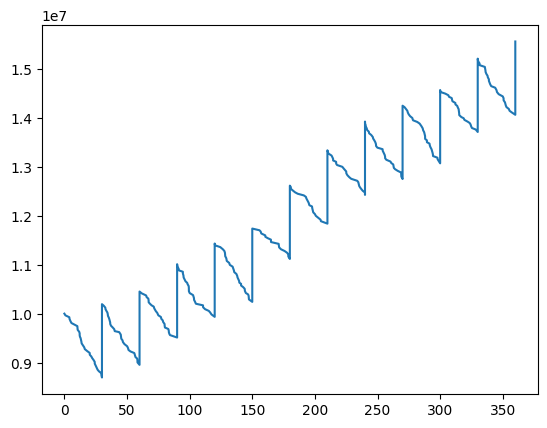

In [ ]:
lt, lc = aseguradora()
plt.plot(lt,lc)
plt.show()

In [ ]:
@jit(nopython = True)
def rep(N = 10**6, T = 365, pol = 150, nc = 10000, c0 = 10**7, nom = 50000):
  l = []
  for i in range(N):
    lam = 1
    mu, sig = 35000, 5000

    ts = -np.log(random())/lam
    tnom = 15
    tpol = 30

    c = c0
    t = 0

    while t<T and min(tnom, tpol) < T:
      t = min(ts,tnom,tpol)
      if t == ts:
        c -= gauss(mu,sig)
        # text = 'Siniestro'
        ts -= np.log(random())/lam
      elif t == tnom:
        c -= nom
        # text = 'Nomina'
        tnom += 15
      else:
        c += pol * nc
        # text = 'Polizas'
        tpol += 30
    ganancia = c-c0
    l.append(ganancia)
  return np.array(l)

4201486.347701847


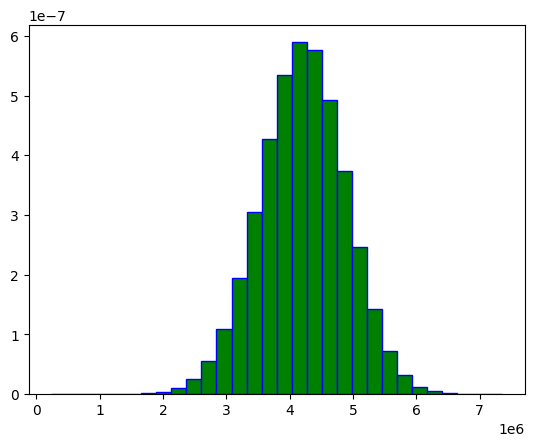

0.42014863477018466


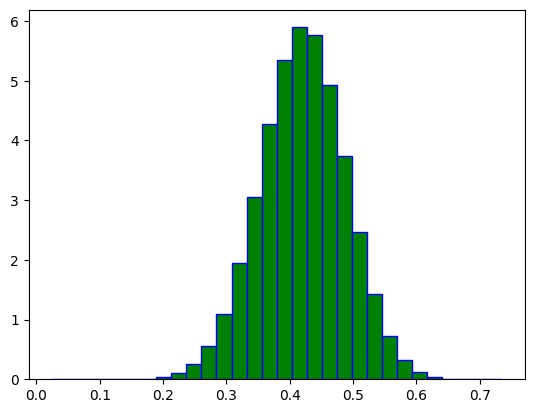

In [ ]:
c0 = 10**7
l= rep(c0 = c0)
print(l.mean())
plt.hist(l, bins = 30, density = True, color = 'g', edgecolor = 'b')
plt.show()

p = l/c0
print(p.mean())
plt.hist(p, bins = 30, density = True, color = 'g', edgecolor = 'b')
plt.show()

100 4199873.596671011 15000
110 4199823.912384885 13636
120 4199659.630656819 12500
130 4199490.491592292 11538
140 4199346.112744478 10714
150 4200453.963813719 10000
160 4200236.11739808 9375
170 4201411.862056279 8824
180 4199110.008416454 8333
190 4200798.586336672 7895
200 4200189.285378964 7500


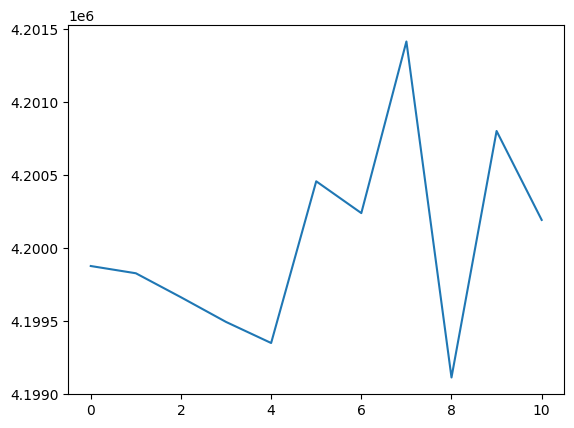

In [ ]:
polizas = [100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
k = []
for pol in polizas:
  n = round(1500000/pol)
  l = rep(N = 10**7, pol = pol, nc = n, c0 = c0)
  k.append(l.mean())
  print(pol, l.mean(), n)
plt.plot(k)
plt.show()